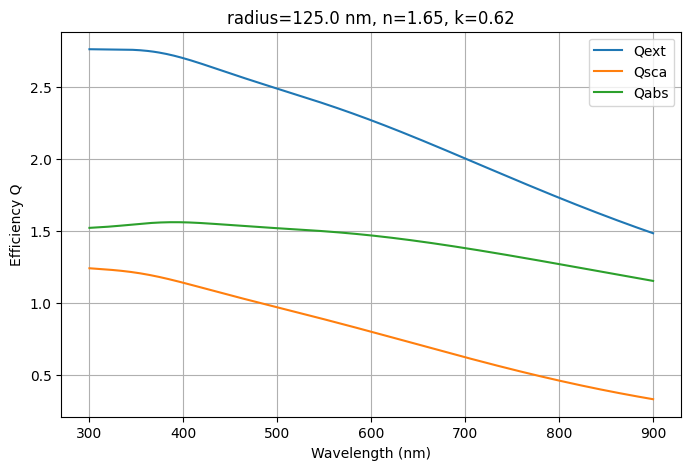

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from nano_mie.dataset import load_dataset

dataset = load_dataset(Path("data/processed/mie_dataset_v1.npz"))

wavelengths_nm = dataset["wavelengths_nm"]
X = dataset["X"]

idx = 79140
radius_nm, n, k = X[idx]

plt.figure(figsize=(8, 5))
plt.plot(wavelengths_nm, dataset["Y_qext"][idx], label="Qext")
plt.plot(wavelengths_nm, dataset["Y_qsca"][idx], label="Qsca")
plt.plot(wavelengths_nm, dataset["Y_qabs"][idx], label="Qabs")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Efficiency Q")
plt.title(f"radius={radius_nm:.1f} nm, n={n:.2f}, k={k:.2f}")
plt.legend()
plt.grid(True)
plt.show()

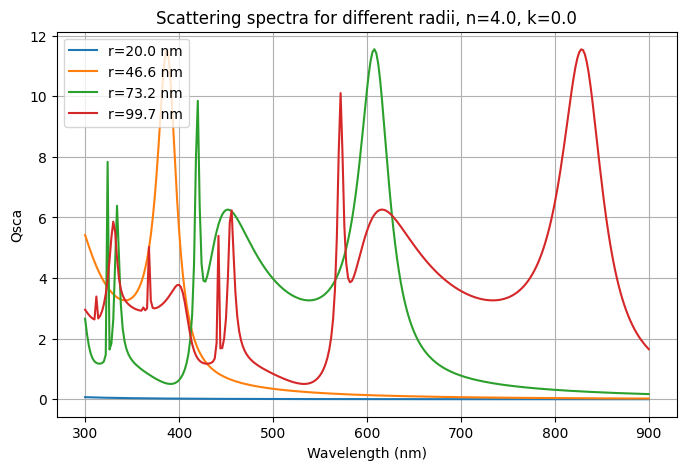

In [ ]:
dataset = load_dataset(Path("data/processed/mie_dataset_v1.npz"))

wavelengths_nm = dataset["wavelengths_nm"]
X = dataset["X"]
Y_qsca = dataset["Y_qsca"]
Y_qabs = dataset["Y_qabs"]

# mesela k=0 ve n=4 civarı olanları seç
n_target = 4.0
k_target = 0.0

mask = np.isclose(X[:, 1], n_target) & np.isclose(X[:, 2], k_target)
indices = np.where(mask)[0]

# farklı radiuslardan birkaç tane seç
chosen = indices[::20][:5]

plt.figure(figsize=(8, 5))
for idx in chosen:
    r, n, k = X[idx]
    plt.plot(wavelengths_nm, Y_qsca[idx], label=f"r={r:.1f} nm")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Qsca")
plt.title(f"Scattering spectra for different radii, n={n_target}, k={k_target}")
plt.legend()
plt.grid(True)
plt.show()